# PROJETO INTRODUÇÃO A INTELIGÊNCIA ARTIFICIAL - MÓDULO 1
## Análise Exploratória de Dados (EDA)
### Lisboa/Porto Air Quality
Objetivo: explorar o dataset processado de qualidade do ar, validar qualidade dos dados e identificar padrões relevantes para modelação.

In [58]:
# Importacao de bibliotecas
try:
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    print("Bibliotecas importadas com sucesso.")
except ImportError as e:
    print(f"Erro de importacao: {e}")
    raise

# Setup de visualizacao/exibicao
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

Bibliotecas importadas com sucesso.


In [59]:
# path relativo para dataset original
original_csv_path = "../data/processed_lisboa_porto_air_quality.csv"

# Carregar e ler dataset
df = pd.read_csv(original_csv_path, sep=";")

print(f"Dataset carregado de: {original_csv_path}")
print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado de: ../data/processed_lisboa_porto_air_quality.csv
Shape: 10768 linhas x 20 colunas


,city,datetime,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,C6H6,NMHC,NOx,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,NaN,NaN,NaN,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,NaN,NaN,NaN,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,NaN,NaN,NaN,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,NaN,NaN,NaN,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,NaN,NaN,NaN,True,2025,9


In [60]:
#ver tipos de dados (features em colunas)
print("Tipos de dados:")
df.dtypes.to_frame("dtype")


Tipos de dados:


,dtype
city,str
datetime,str
CO,float64
NO2,float64
O3,float64
PM10,float64
PM2.5,float64
SO2,float64
temperature_c,float64
humidity_percent,float64


In [61]:
# distribuicao de nulos por linha (x linhas com 0, 1, 2, ... nulos)
nulls_per_row = df.isna().sum(axis=1)
rows_by_null_count = nulls_per_row.value_counts().sort_index().rename_axis("n_nulls_na_linha").to_frame("n_linhas")
rows_by_null_count["pct_linhas"] = ((rows_by_null_count["n_linhas"] / len(df)) * 100).round(2)

print("Distribuicao de nulos por linha:")
display(rows_by_null_count)

Distribuicao de nulos por linha:


,n_linhas,pct_linhas
n_nulls_na_linha,,
3,1442,13.39
8,827,7.68
9,6138,57.00
10,467,4.34
11,390,3.62
12,1486,13.80
13,6,0.06
14,12,0.11


In [62]:
# Resumo de qualidade (missing + cardinalidade), já ordenado por missing
summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "unique_pct": ((df.nunique(dropna=True) / len(df)) * 100).round(2),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Resumo de missing e cardinalidade (ordenado):")
display(summary)

Resumo de missing e cardinalidade (ordenado):


,missing_count,missing_pct,n_unique,unique_pct
NMHC,9854,91.51,429,3.98
O3,9326,86.61,1281,11.90
PM10,9326,86.61,1179,10.95
PM2.5,9326,86.61,1119,10.39
SO2,9326,86.61,807,7.49
wind_direction_deg,9326,86.61,299,2.78
wind_speed_kmh,9326,86.61,242,2.25
pressure_hpa,9326,86.61,154,1.43
precipitation_mm,9326,86.61,18,0.17
NOx,3050,28.32,925,8.59


In [63]:
# Operacao 4: contar duplicados
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


In [64]:
# Operacao 6: detetar colunas temporais automaticamente
potential_date_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ["date", "time", "data", "timestamp"])
]
print(f"Colunas potencialmente temporais: {potential_date_cols if potential_date_cols else 'nenhuma'}")

Colunas potencialmente temporais: ['datetime']


In [65]:
# Estatisticas descritivas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print(f"Colunas numericas ({len(num_cols)}): {num_cols}")
print(f"Colunas nao numericas ({len(cat_cols)}): {cat_cols}")

if num_cols:
    display(df[num_cols].describe().T)
else:
    print("Sem colunas numericas para descrever.")

if cat_cols:
    cat_cardinality = df[cat_cols].nunique(dropna=True).sort_values(ascending=False)
    display(cat_cardinality.to_frame("n_unique"))

Colunas numericas (17): ['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_kmh', 'wind_direction_deg', 'precipitation_mm', 'C6H6', 'NMHC', 'NOx', 'year', 'month']
Colunas nao numericas (3): ['city', 'datetime', 'air_quality_good']


,count,mean,std,min,25%,50%,75%,max
CO,9116.0,1.971439,1.408473,0.10,0.9400,1.600,2.6000,11.90
NO2,9157.0,99.959433,54.052344,2.00,57.1200,98.000,134.0000,340.00
O3,1442.0,69.301706,16.780429,28.22,56.5525,69.205,81.3100,114.68
PM10,1442.0,21.614896,9.428184,1.84,13.9525,20.110,28.0200,58.57
PM2.5,1442.0,15.138800,6.889596,0.10,9.6500,14.080,19.9400,38.75
SO2,1442.0,6.453259,3.050010,0.10,4.1225,6.010,8.3975,18.36
temperature_c,10433.0,18.471341,8.327228,-1.90,12.7000,18.200,23.8000,44.60
humidity_percent,10433.0,51.978213,18.949539,9.20,37.6000,51.700,65.6000,100.00
pressure_hpa,1442.0,1019.587864,3.062214,1002.90,1018.2000,1020.100,1021.6000,1025.70
wind_speed_kmh,1442.0,8.953051,6.143344,0.00,3.7000,7.300,13.0000,28.00


,n_unique
datetime,10047
city,3
air_quality_good,2


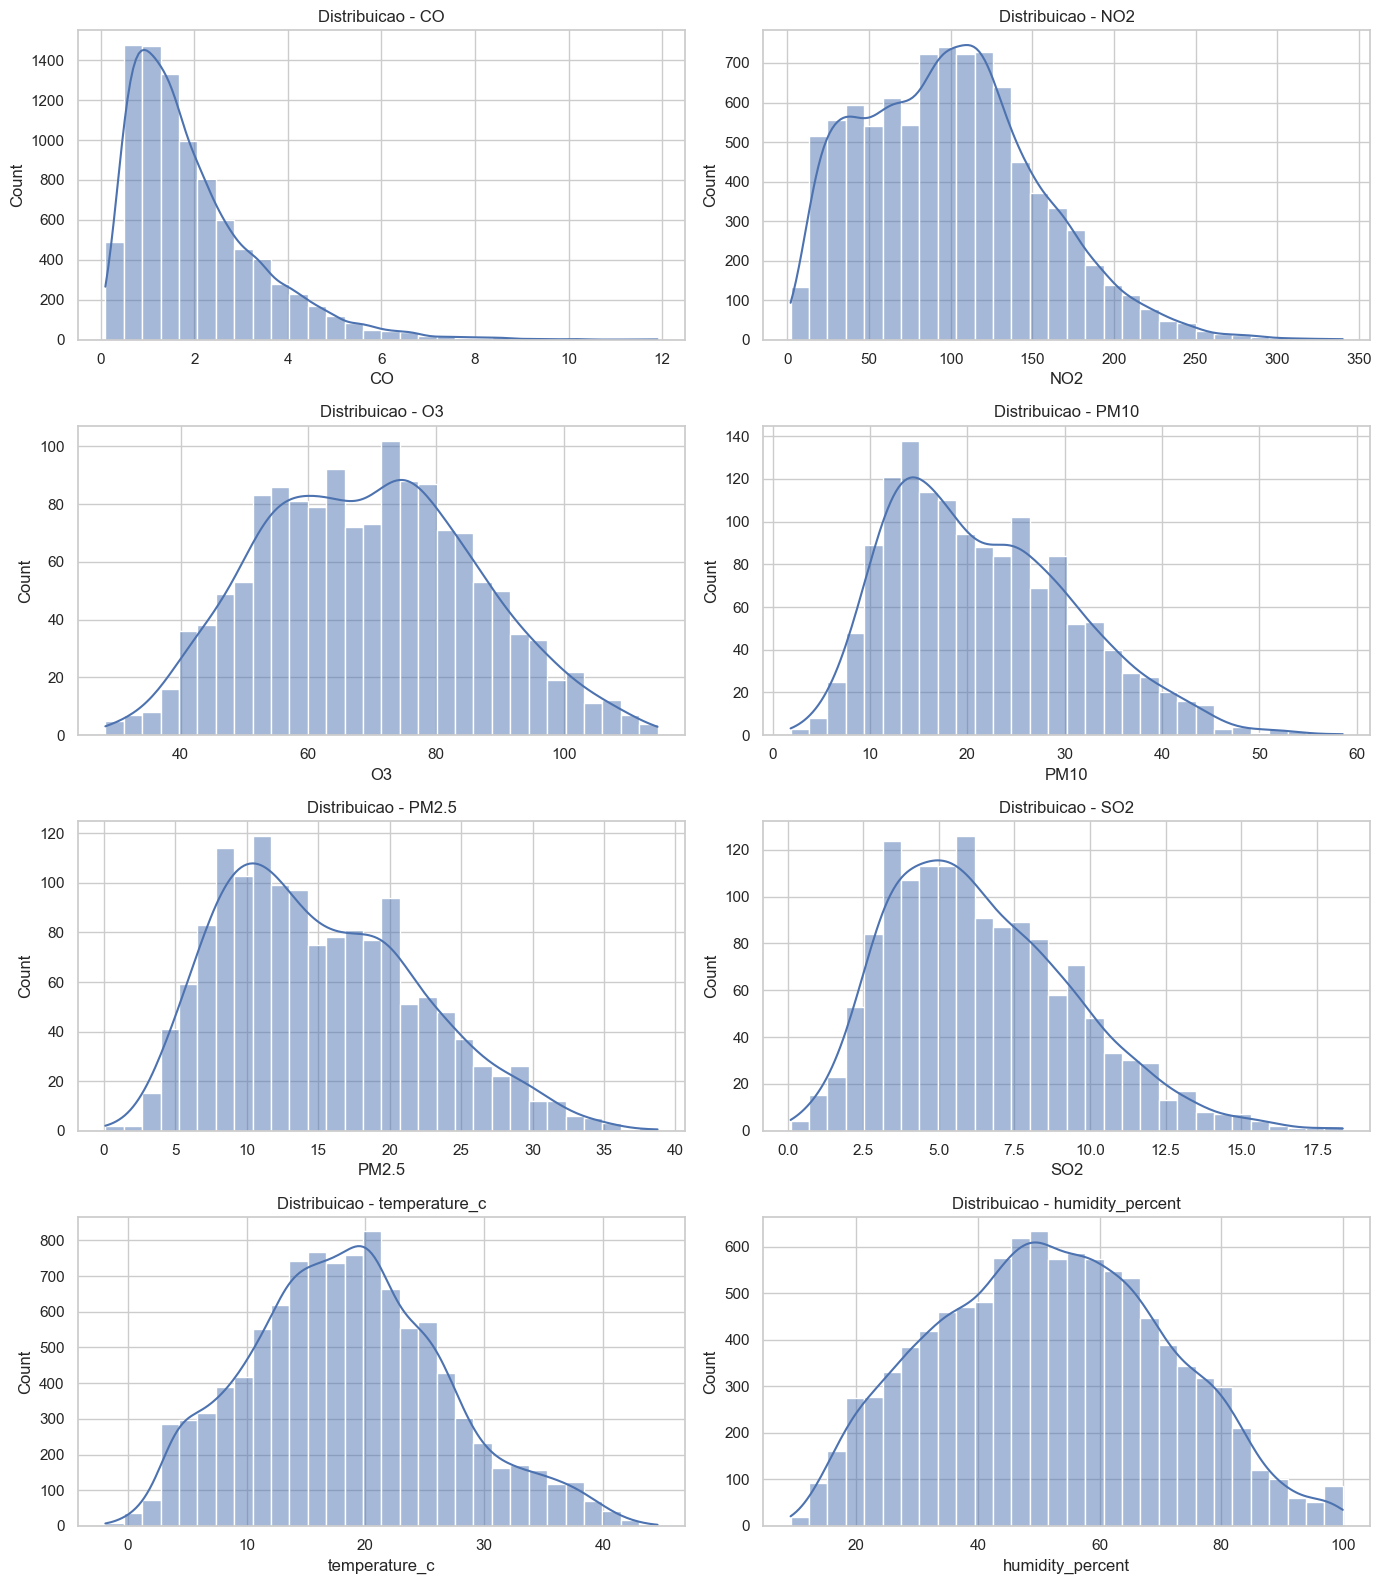

In [66]:
# Distribuicoes das variaveis numericas (limitado para legibilidade)
if num_cols:
    plot_cols = num_cols[:8]
    n_cols = 2
    n_rows = int(np.ceil(len(plot_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f"Distribuicao - {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Sem colunas numericas para visualizar.")

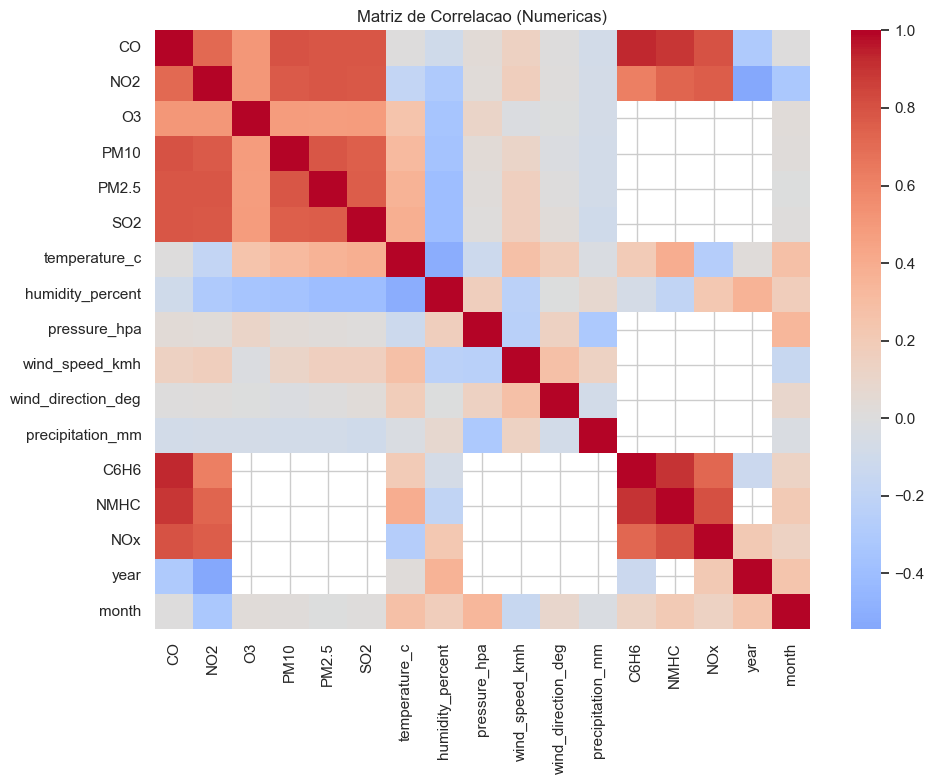

abs_corr
CO    C6H6  0.931078
C6H6  NMHC  0.902559
NMHC  CO    0.889734
      NOx   0.812685
CO    PM10  0.800523
      NOx   0.795028
PM2.5 CO    0.788720
CO    SO2   0.783355
PM2.5 NO2   0.780743
      PM10  0.780225

In [67]:
# Correlacoes entre variaveis numericas
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Matriz de Correlacao (Numericas)")
    plt.tight_layout()
    plt.show()

    # Top correlacoes absolutas (sem diagonal)
    corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
    top_pairs = corr_abs.unstack().dropna().sort_values(ascending=False).drop_duplicates().head(10)
    display(top_pairs.to_frame("abs_corr"))
else:
    print("Correlacao requer pelo menos 2 colunas numericas.")

A usar coluna de agrupamento: city


,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,C6H6,NMHC,NOx,year,month
city,,,,,,,,,,,,,,,,,
Lisboa,1.093107,32.076893,71.735673,22.919362,16.618571,7.400860,20.884882,62.732316,1019.266436,10.390846,267.934813,0.002358,NaN,NaN,NaN,2025.000000,9.135922
Porto,0.919986,27.326061,66.867739,20.310430,13.659029,5.505659,17.972122,75.442441,1019.909293,7.515257,201.124827,0.085576,NaN,NaN,NaN,2025.000000,9.135922
UCI_Dataset,2.152750,113.091251,NaN,NaN,NaN,NaN,18.317829,49.234201,NaN,NaN,NaN,NaN,10.083105,218.811816,246.896735,2004.240939,6.307420


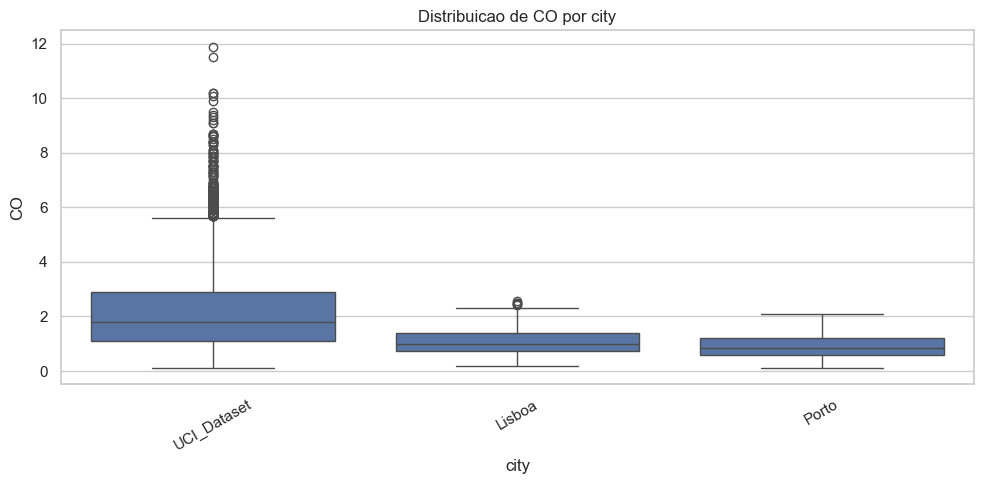

In [68]:
# Analises por cidade/estacao (se existir coluna categorica apropriada)
city_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["city", "cidade", "station", "estacao", "location", "local"])]

if city_like_cols and num_cols:
    group_col = city_like_cols[0]
    print(f"A usar coluna de agrupamento: {group_col}")

    group_summary = df.groupby(group_col)[num_cols].mean(numeric_only=True).sort_index()
    display(group_summary)

    top_num = num_cols[0]
    plt.figure(figsize=(10, 5))
    order = df[group_col].value_counts().index
    sns.boxplot(data=df, x=group_col, y=top_num, order=order)
    plt.title(f"Distribuicao de {top_num} por {group_col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Sem coluna evidente de cidade/estacao ou sem colunas numericas.")

In [69]:
# Preparacao temporal (se houver coluna datetime)
if "datetime" in df.columns:
    # Formato esperado: dd/mm/yy HH:MM
    dt = pd.to_datetime(df["datetime"], format="%d/%m/%y %H:%M", errors="coerce")
    df_eda = df.copy()
    df_eda["datetime_parsed"] = dt
    df_eda["date"] = dt.dt.date
    df_eda["hour"] = dt.dt.hour
    df_eda["year_parsed"] = dt.dt.year
    print(f"Registos com datetime valido: {df_eda['datetime_parsed'].notna().sum()} / {len(df_eda)}")
else:
    df_eda = df.copy()
    print("Sem coluna 'datetime'; a analise temporal sera ignorada.")

Registos com datetime valido: 10768 / 10768


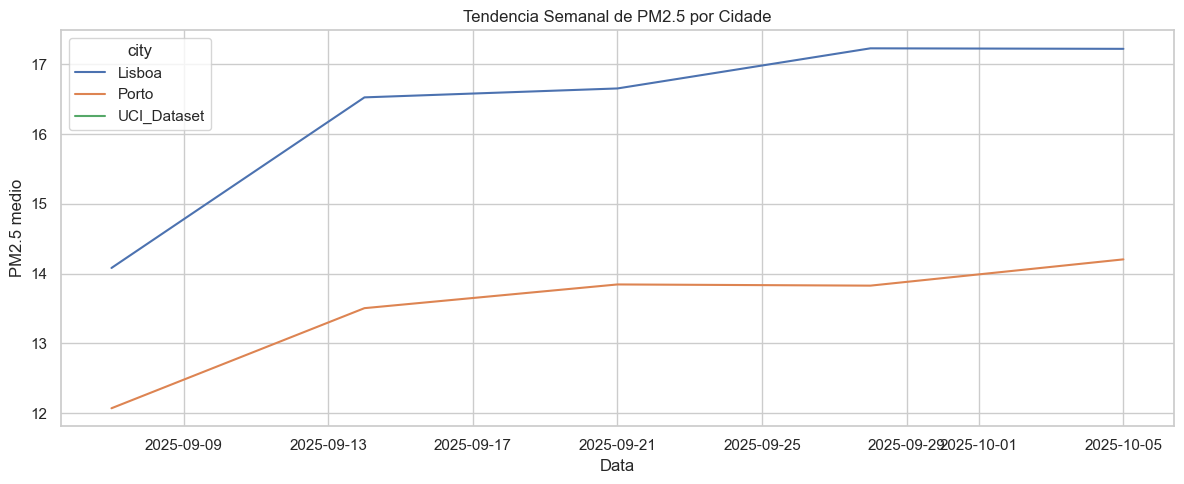


Resumo rapido de insights:
- Linhas: 10768 | Colunas: 20
- Duplicados: 0
- Top colunas com missing (%):
NMHC                91.51
PM10                86.61
O3                  86.61
PM2.5               86.61
precipitation_mm    86.61
pressure_hpa        86.61
- Distribuicao por city:
city
UCI_Dataset    9326
Lisboa          721
Porto           721
- Distribuicao de air_quality_good:
air_quality_good
False    6193
True     4575
- Par com maior correlacao absoluta: CO vs C6H6


In [70]:
# Tendencia temporal e resumo de insights
if {"datetime_parsed", "city"}.issubset(df_eda.columns) and "PM2.5" in df_eda.columns:
    trend = (
        df_eda.dropna(subset=["datetime_parsed"])
        .set_index("datetime_parsed")
        .groupby("city")["PM2.5"]
        .resample("W")
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=trend, x="datetime_parsed", y="PM2.5", hue="city")
    plt.title("Tendencia Semanal de PM2.5 por Cidade")
    plt.xlabel("Data")
    plt.ylabel("PM2.5 medio")
    plt.tight_layout()
    plt.show()

print("\nResumo rapido de insights:")
print(f"- Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
print(f"- Duplicados: {df.duplicated().sum()}")

missing_cols = (df.isna().mean() * 100).sort_values(ascending=False)
print("- Top colunas com missing (%):")
print(missing_cols.head(6).round(2).to_string())

if "city" in df.columns:
    print("- Distribuicao por city:")
    print(df["city"].value_counts(dropna=False).to_string())

if "air_quality_good" in df.columns:
    print("- Distribuicao de air_quality_good:")
    print(df["air_quality_good"].value_counts(dropna=False).to_string())

if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
    strongest = corr_abs.unstack().dropna().sort_values(ascending=False).index[0]
    print(f"- Par com maior correlacao absoluta: {strongest[0]} vs {strongest[1]}")

## Pre-processamento dos dados

Nesta secção aplicamos um protocolo objetivo para documentar exatamente o que é feito aos dados (versão oficial única):

1. Remover duplicados.
2. Remover features com mais de 75% de missing values, **exceto** features críticas para o sistema de regras.
3. Criar `CO_8h_avg` (média móvel 8h por cidade, mínimo 6 valores válidos).
4. Detetar outliers por IQR (Q1-1.5*IQR, Q3+1.5*IQR).
5. Criar versão normalizada (z-score) apenas para análise auxiliar.

Nota metodológica:
- Para o motor de regras, usamos unidades físicas originais (não normalizadas).
- Outliers não são removidos automaticamente no pipeline de regras, porque eventos extremos podem ser casos de interesse.
- Este notebook exporta uma única base oficial para a pipeline: `outputs/preprocessed_for_rules.csv`.

In [71]:
from pathlib import Path
import json

# Configuração do protocolo
MISSING_THRESHOLD = 75.0
CRITICAL_RULE_FEATURES = {
    "city", "datetime", "air_quality_good", "year", "month",
    "NO2", "PM10", "PM2.5", "O3", "CO", "SO2",
    "temperature_c", "humidity_percent", "wind_speed_kmh", "precipitation_mm"
}

# Ler features realmente usadas nas regras (se regras.json existir)
rules_path = Path("regras.json")
rule_feature_alias = {"PM2_5": "PM2.5"}
required_rule_features = set()

if rules_path.exists():
    rules_data = json.loads(rules_path.read_text(encoding="utf-8"))
    stack = [r.get("condition", {}) for r in rules_data.get("rules", [])]

    while stack:
        cond = stack.pop()
        if not isinstance(cond, dict):
            continue
        if "variable" in cond and cond["variable"]:
            mapped = rule_feature_alias.get(cond["variable"], cond["variable"])
            required_rule_features.add(mapped)
        stack.extend(cond.get("conditions", []) or [])
        stack.extend(cond.get("subconditions", []) or [])

# Proteger para drop de colunas: críticas + efetivamente usadas nas regras
protected_features = CRITICAL_RULE_FEATURES.union(required_rule_features)

# 1) Cópia de trabalho
prep = df.copy()
initial_shape = prep.shape

# 2) Parsing de datetime para permitir rolling por cidade em ordem temporal
if "datetime" in prep.columns:
    prep["datetime_parsed"] = pd.to_datetime(prep["datetime"], format="%d/%m/%y %H:%M", errors="coerce")

# 3) Remoção de duplicados (linha completa)
duplicates_removed = int(prep.duplicated().sum())
prep = prep.drop_duplicates().copy()

# 4) Missing report + drop de colunas >75% missing (exceto protegidas)
missing_pct = (prep.isna().mean() * 100).sort_values(ascending=False)
cols_over_threshold = [c for c in prep.columns if missing_pct.get(c, 0.0) > MISSING_THRESHOLD]
cols_dropped = [c for c in cols_over_threshold if c not in protected_features]
prep = prep.drop(columns=cols_dropped, errors="ignore")

# 5) Derivada CO_8h_avg (rolling 8 por cidade, min 6)
if {"city", "CO"}.issubset(prep.columns):
    if "datetime_parsed" in prep.columns:
        prep = prep.sort_values(["city", "datetime_parsed"], kind="stable")
    else:
        prep = prep.sort_values(["city"], kind="stable")

    prep["CO_8h_avg"] = (
        prep.groupby("city")["CO"]
        .transform(lambda x: x.rolling(window=8, min_periods=6).mean())
    )

# 6) Deteção de outliers por IQR (sem remoção automática)
numeric_cols = prep.select_dtypes(include=np.number).columns.tolist()
outlier_summary = []
for col in numeric_cols:
    s = prep[col].dropna()
    if s.empty:
        continue
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        n_out = 0
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_out = int(((prep[col] < lower) | (prep[col] > upper)).sum())
    outlier_summary.append({"feature": col, "n_outliers": n_out})

outlier_df = pd.DataFrame(outlier_summary).sort_values("n_outliers", ascending=False)

# 7) Normalização z-score (versão separada para análise; não usada no motor de regras)
norm_base_cols = [
    c for c in numeric_cols
    if c not in {"year", "month"}
 ]
prep_norm = prep.copy()
for col in norm_base_cols:
    std = prep_norm[col].std(skipna=True)
    mean = prep_norm[col].mean(skipna=True)
    if pd.notna(std) and std > 0:
        prep_norm[f"{col}_z"] = (prep_norm[col] - mean) / std

print("Resumo de pré-processamento (versão oficial única)")
print("- Shape inicial:", initial_shape)
print("- Duplicados removidos:", duplicates_removed)
print("- Colunas >75% missing:", len(cols_over_threshold))
print("- Colunas removidas (>75% e não protegidas):", cols_dropped if cols_dropped else "nenhuma")
print("- Shape final (prep):", prep.shape)
print("- CO_8h_avg criada:", "CO_8h_avg" in prep.columns)
print("- Features obrigatórias das regras encontradas:", [c for c in sorted(required_rule_features) if c in prep.columns])

display(missing_pct.to_frame("missing_pct").head(15))
display(outlier_df.head(15))

Resumo de pré-processamento (versão oficial única)
- Shape inicial: (10768, 20)
- Duplicados removidos: 0
- Colunas >75% missing: 9
- Colunas removidas (>75% e não protegidas): ['pressure_hpa', 'wind_direction_deg', 'NMHC']
- Shape final (prep): (10768, 19)
- CO_8h_avg criada: True
- Features obrigatórias das regras encontradas: ['CO_8h_avg', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'humidity_percent', 'precipitation_mm', 'temperature_c', 'wind_speed_kmh']


,missing_pct
NMHC,91.511887
PM2.5,86.608470
SO2,86.608470
PM10,86.608470
O3,86.608470
wind_direction_deg,86.608470
wind_speed_kmh,86.608470
precipitation_mm,86.608470
pressure_hpa,86.608470
NOx,28.324666


,feature,n_outliers
12,year,1442
11,NOx,435
0,CO,344
10,C6H6,228
14,CO_8h_avg,171
1,NO2,66
6,temperature_c,39
5,SO2,17
3,PM10,7
8,wind_speed_kmh,5


In [72]:
# 8) Guardar artefactos para rastreabilidade
out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

prep.to_csv(out_dir / "preprocessed_for_rules.csv", sep=";", index=False)
prep_norm.to_csv(out_dir / "preprocessed_with_zscores.csv", sep=";", index=False)

decisions = pd.DataFrame([
    {"step": "drop_duplicates", "detail": f"removed={duplicates_removed}"},
    {"step": "missing_threshold", "detail": f"threshold={MISSING_THRESHOLD}%"},
    {"step": "columns_over_threshold", "detail": ", ".join(cols_over_threshold) if cols_over_threshold else "none"},
    {"step": "columns_dropped", "detail": ", ".join(cols_dropped) if cols_dropped else "none"},
    {"step": "protected_features", "detail": ", ".join(sorted(protected_features))},
    {"step": "co_8h_avg", "detail": "rolling=8, min_periods=6, by=city"},
    {"step": "outlier_method", "detail": "IQR (1.5*IQR), detection only"},
    {"step": "normalization", "detail": "z-score columns with std>0 (analysis copy only)"},
])

decisions.to_csv(out_dir / "preprocessing_decisions.csv", index=False)

print("Ficheiros gravados em Module_1/outputs:")
print("- outputs/preprocessed_for_rules.csv")
print("- outputs/preprocessed_with_zscores.csv")
print("- outputs/preprocessing_decisions.csv")
display(decisions)

Ficheiros gravados em Module_1/outputs:
- outputs/preprocessed_for_rules.csv
- outputs/preprocessed_with_zscores.csv
- outputs/preprocessing_decisions.csv


,step,detail
0,drop_duplicates,removed=0
1,missing_threshold,threshold=75.0%
2,columns_over_threshold,"O3, PM10, PM2.5, SO2, pressure_hpa, wind_speed..."
3,columns_dropped,"pressure_hpa, wind_direction_deg, NMHC"
4,protected_features,"CO, CO_8h_avg, NO2, O3, PM10, PM2.5, SO2, air_..."
5,co_8h_avg,"rolling=8, min_periods=6, by=city"
6,outlier_method,"IQR (1.5*IQR), detection only"
7,normalization,z-score columns with std>0 (analysis copy only)
